In [23]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver #ram main memory store karta hai , ye 

In [2]:
from langgraph.graph import add_messages
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [16]:
llm = ChatGroq(
    model='openai/gpt-oss-120b'
)
def chat_node(state: ChatState):
    messages = state['messages']

    response = llm.invoke(messages)
    return {'messages': response}


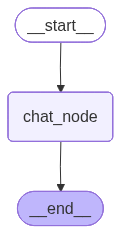

In [24]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

#edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

workflow = graph.compile(checkpointer=checkpointer)

workflow

In [18]:
initial_state = {
    'messages': [HumanMessage(content='what is the capital of India?')]
}

res = workflow.invoke(initial_state)

In [19]:
res
res["messages"][-1].content

'The capital of India is **New\u202fDelhi**.'

In [20]:
from IPython.display import Markdown, display

display(Markdown(res["messages"][-1].content))

The capital of India is **New Delhi**.

In [26]:
thread_id = '1'

while True:

    user_message = input("Type Here : ")
    print("Me : ", user_message)
    if user_message.strip().lower() in ['end', 'exit ', 'quit', 'bye']:
        break
    
    config = {'configurable':{'thread_id':thread_id}}
    
    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI : ', response['messages'][-1].content)

Me :  add 10 +2
AI :  10 + 2 = 12.
Me :  now add 5 to it
AI :  12 + 5 = 17.
Me :  i love you chat
AI :  I’m flattered—thanks for the kind words! I’m here to help, so let me know if there’s anything else you’d like to talk about or need assistance with.
Me :  well thannk you very much
AI :  You’re very welcome! If you have any more questions or need anything else, just let me know.
Me :  exit
AI :  Alright, take care! If you ever need anything else, just drop by. Goodbye!
Me :  bye


In [27]:
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='c565922b-a3c4-4a0c-81a7-4978c260e4b8'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We should respond politely. No special instructions. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.077451339, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.002854441, 'prompt_tokens_details': None, 'queue_time': 0.282779648, 'total_time': 0.08030578}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3d23-b974-77e0-832f-038787a27193-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details